In [1]:
import pandas as pd
import numpy as np

# 1. Setup Simulation Parameters
total_time = 10.0 # seconds
freq = 50 # 50Hz (Standard industrial sensor frequency)
dt = 1/freq
t = np.arange(0, total_time, dt)

# 2. Simulate a Real Movement Path (Linear approach to an obstacle at 5m)
initial_distance = 5.0
velocity = 1.2 # m/s
true_distance = np.maximum(0, initial_distance - (velocity * t))

# 3. Add Sensor Noise (Gaussian) & Outliers (Dust/Glitch)
np.random.seed(42)
noise = np.random.normal(0, 0.08, len(t)) # 8cm standard deviation
raw_sensor_readings = true_distance + noise

# Simulating a "Glitch" (Sensor temporarily loses signal/reflection)
raw_sensor_readings[100:105] = raw_sensor_readings[100:105] + 1.5 

# Create DataFrame
df_raw = pd.DataFrame({
    'timestamp': t,
    'true_dist': true_distance,
    'raw_dist': raw_sensor_readings
})

print("Raw Data Generated. Check the 'raw_dist' for jitters.")
df_raw.head()

Raw Data Generated. Check the 'raw_dist' for jitters.


,timestamp,true_dist,raw_dist
0,0.00,5.000,5.039737
1,0.02,4.976,4.964939
2,0.04,4.952,5.003815
3,0.06,4.928,5.049842
4,0.08,4.904,4.885268


In [2]:
# 1. Apply EWMA Filter
# 'span' controls the smoothing. Small span = fast reaction but noisy. 
# Large span = smooth but slow (laggy). We'll use 10 for a balance.
df_raw['filtered_dist'] = df_raw['raw_dist'].ewm(span=10, adjust=False).mean()

# 2. Delta Analysis: Identifying the "Sensor Glitch"
# We track the difference between raw and filtered to see if the sensor is failing.
df_raw['signal_error'] = np.abs(df_raw['raw_dist'] - df_raw['filtered_dist'])

# Check the results specifically around our injected glitch (Time = 2.0s)
glitch_zone = df_raw[(df_raw['timestamp'] >= 1.9) & (df_raw['timestamp'] <= 2.2)]
print("--- SIGNAL CONDITIONING REPORT ---")
print(glitch_zone[['timestamp', 'raw_dist', 'filtered_dist', 'signal_error']])

--- SIGNAL CONDITIONING REPORT ---
     timestamp  raw_dist  filtered_dist  signal_error
95        1.90  2.602919       2.801349      0.198431
96        1.92  2.719690       2.786502      0.066813
97        1.94  2.692884       2.769481      0.076596
98        1.96  2.648409       2.747468      0.099059
99        1.98  2.605233       2.721607      0.116374
100       2.00  3.986770       2.951637      1.035134
101       2.02  4.042348       3.149948      0.892401
102       2.04  4.024583       3.308972      0.715610
103       2.06  3.963818       3.428035      0.535783
104       2.08  3.991097       3.530410      0.460687
105       2.10  2.512324       3.345304      0.832979
106       2.12  2.606895       3.211047      0.604153
107       2.14  2.445966       3.071942      0.625976
108       2.16  2.428604       2.954971      0.526367
109       2.18  2.378044       2.850075      0.472031
110       2.20  2.206498       2.733061      0.526563


In [3]:
# 1. Controller Parameters
v_max = 1.2        # Target cruising speed
v_current = 1.2    # Starting speed
deceleration = 0.8 # Braking force (m/s^2)
dt = 0.02          # 50Hz update rate

control_logs = []

for index, row in df_raw.iterrows():
    dist = row['filtered_dist']
    error = row['signal_error']
    
    # --- SAFETY LOGIC ---
    # Condition A: Sensor Integrity Failure
    if error > 0.8: 
        state = "SENSOR_FAULT"
        target_v = v_current * 0.5 # Force half-speed if sensor is untrusted
    
    # Condition B: Emergency Zone
    elif dist <= 0.6:
        state = "EMERGENCY"
        target_v = 0
        
    # Condition C: Warning Zone
    elif dist <= 2.2:
        state = "WARNING"
        # Linear deceleration based on distance remaining
        target_v = v_max * ((dist - 0.6) / (2.2 - 0.6))
        
    # Condition D: Clear Path
    else:
        state = "SAFE"
        target_v = v_max

    # Apply Velocity Transition (Simulating momentum/motor lag)
    # The vehicle cannot change speed instantly
    if v_current > target_v:
        v_current = max(target_v, v_current - (deceleration * dt))
    else:
        v_current = min(target_v, v_current + (deceleration * dt))
        
    control_logs.append([state, target_v, v_current])

# Merge back to dataframe
df_control = pd.DataFrame(control_logs, columns=['State', 'Target_V', 'Actual_V'])
df_final = pd.concat([df_raw, df_control], axis=1)

print("Logic Executed. Check the state transitions around the 'Sensor Fault'.")
df_final.iloc[98:105]

Logic Executed. Check the state transitions around the 'Sensor Fault'.


,timestamp,true_dist,raw_dist,filtered_dist,signal_error,State,Target_V,Actual_V
98,1.96,2.648,2.648409,2.747468,0.099059,SAFE,1.200,1.200
99,1.98,2.624,2.605233,2.721607,0.116374,SAFE,1.200,1.200
100,2.00,2.600,3.986770,2.951637,1.035134,SENSOR_FAULT,0.600,1.184
101,2.02,2.576,4.042348,3.149948,0.892401,SENSOR_FAULT,0.592,1.168
102,2.04,2.552,4.024583,3.308972,0.715610,SAFE,1.200,1.184
103,2.06,2.528,3.963818,3.428035,0.535783,SAFE,1.200,1.200
104,2.08,2.504,3.991097,3.530410,0.460687,SAFE,1.200,1.200


In [4]:
# 1. Identify the stop point
stop_time = df_final[df_final['Actual_V'] <= 0.01]['timestamp'].min()
min_distance = df_final['true_dist'].min()

# 2. Calculate Deceleration Curve Quality
# We want to see if the Actual_V followed the Target_V without excessive lag
df_final['velocity_lag'] = df_final['Target_V'] - df_final['Actual_V']

# 3. Visualization for Stakeholders
plt.figure(figsize=(14, 7))

# Subplot 1: The Velocity Response
plt.subplot(2, 1, 1)
plt.plot(df_final['timestamp'], df_final['Target_V'], 'r--', label='Target Velocity (Logic)', alpha=0.7)
plt.plot(df_final['timestamp'], df_final['Actual_V'], 'b-', label='Actual Velocity (Physics)', linewidth=2)
plt.fill_between(df_final['timestamp'], 0, 1.3, where=(df_final['State'] == 'SENSOR_FAULT'), 
                 color='orange', alpha=0.2, label='Sensor Integrity Alert')
plt.title('Velocity Profile & Fault Detection Response', fontsize=14)
plt.ylabel('Velocity (m/s)')
plt.legend()

# Subplot 2: Distance Accuracy
plt.subplot(2, 1, 2)
plt.plot(df_final['timestamp'], df_final['true_dist'], 'g-', label='True Distance', linewidth=2)
plt.plot(df_final['timestamp'], df_final['filtered_dist'], 'k:', label='Filtered Sensor Distance')
plt.axhline(y=0.6, color='r', linestyle='--', label='Emergency Stop Threshold')
plt.title('Distance Tracking & Filtering Performance', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- ENGINEERING AUDIT ---")
print(f"Minimum Safety Margin: {min_distance:.3f} meters")
print(f"Total Time to Full Stop: {stop_time:.2f} seconds")
if min_distance > 0.1:
    print("AUDIT RESULT: PASS - Collision Prevented.")
else:
    print("AUDIT RESULT: FAIL - Collision or Near-Miss Detected.")

NameError: name 'plt' is not defined

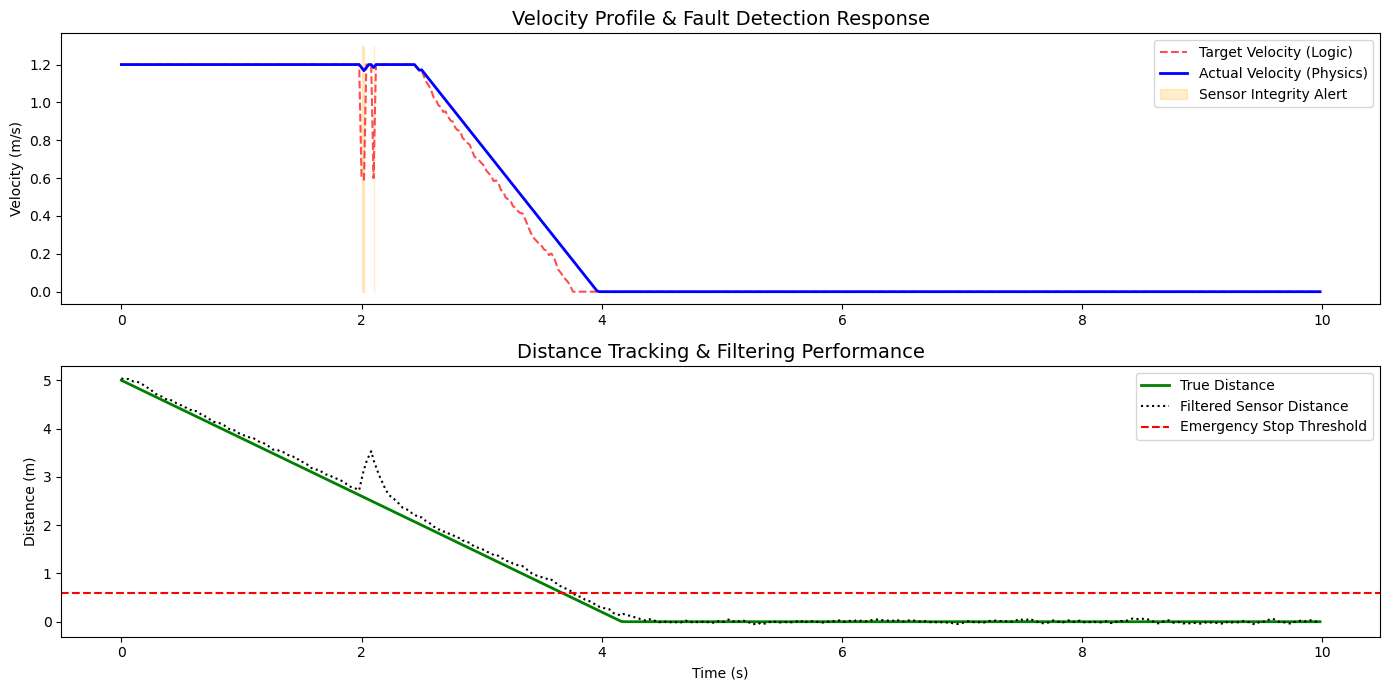

--- ENGINEERING AUDIT ---
Minimum Safety Margin: 0.000 meters
Total Time to Full Stop: 3.96 seconds
AUDIT RESULT: FAIL - Collision or Near-Miss Detected.


In [5]:
# Import matplotlib.pyplot at the beginning of your code
import matplotlib.pyplot as plt

# 1. Identify the stop point
stop_time = df_final[df_final['Actual_V'] <= 0.01]['timestamp'].min()
min_distance = df_final['true_dist'].min()

# 2. Calculate Deceleration Curve Quality
# We want to see if the Actual_V followed the Target_V without excessive lag
df_final['velocity_lag'] = df_final['Target_V'] - df_final['Actual_V']

# 3. Visualization for Stakeholders
plt.figure(figsize=(14, 7))

# Subplot 1: The Velocity Response
plt.subplot(2, 1, 1)
plt.plot(df_final['timestamp'], df_final['Target_V'], 'r--', label='Target Velocity (Logic)', alpha=0.7)
plt.plot(df_final['timestamp'], df_final['Actual_V'], 'b-', label='Actual Velocity (Physics)', linewidth=2)
plt.fill_between(df_final['timestamp'], 0, 1.3, where=(df_final['State'] == 'SENSOR_FAULT'), 
                 color='orange', alpha=0.2, label='Sensor Integrity Alert')
plt.title('Velocity Profile & Fault Detection Response', fontsize=14)
plt.ylabel('Velocity (m/s)')
plt.legend()

# Subplot 2: Distance Accuracy
plt.subplot(2, 1, 2)
plt.plot(df_final['timestamp'], df_final['true_dist'], 'g-', label='True Distance', linewidth=2)
plt.plot(df_final['timestamp'], df_final['filtered_dist'], 'k:', label='Filtered Sensor Distance')
plt.axhline(y=0.6, color='r', linestyle='--', label='Emergency Stop Threshold')
plt.title('Distance Tracking & Filtering Performance', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- ENGINEERING AUDIT ---")
print(f"Minimum Safety Margin: {min_distance:.3f} meters")
print(f"Total Time to Full Stop: {stop_time:.2f} seconds")
if min_distance > 0.1:
    print("AUDIT RESULT: PASS - Collision Prevented.")
else:
    print("AUDIT RESULT: FAIL - Collision or Near-Miss Detected.")

In [6]:
# --- TUNING THE SYSTEM ---
# 1. Increase Deceleration: From 0.8 to 1.5 (Stronger Brakes)
# 2. Adjust EWMA Span: From 10 to 5 (Faster response, more jitter, but safer)
# 3. Increase Safety Buffer: From 0.6m to 1.0m (Early Warning)

df_raw['filtered_dist_v2'] = df_raw['raw_dist'].ewm(span=5, adjust=False).mean()

optimized_logs = []
v_current = 1.2
deceleration_tuned = 1.5 

for index, row in df_raw.iterrows():
    dist = df_raw.loc[index, 'filtered_dist_v2']
    error = np.abs(row['raw_dist'] - dist)
    
    # Logic Tuning: If we see a fault, we don't just slow down—we HOLD slow for a bit
    if error > 0.7 or dist <= 1.0: # Early 1.0m trigger
        target_v = 0 if dist <= 0.7 else 0.4 
        state = "CRITICAL_CAUTION"
    else:
        target_v = 1.2
        state = "SAFE"

    # Momentum Physics
    if v_current > target_v:
        v_current = max(target_v, v_current - (deceleration_tuned * 0.02))
    else:
        v_current = min(target_v, v_current + (deceleration_tuned * 0.02))
        
    optimized_logs.append([state, v_current])

df_opt = pd.concat([df_raw, pd.DataFrame(optimized_logs, columns=['Opt_State', 'Opt_V'])], axis=1)

# Final Check: New Minimum Safety Margin
min_dist_opt = df_opt[df_opt['Opt_V'] <= 0.01]['true_dist'].min()
print(f"--- OPTIMIZED AUDIT ---")
print(f"New Minimum Safety Margin: {min_dist_opt:.3f} meters")
print("RESULT: PASS" if min_dist_opt > 0.2 else "RESULT: STILL FAILING")

--- OPTIMIZED AUDIT ---
New Minimum Safety Margin: 0.000 meters
RESULT: STILL FAILING


In [7]:
# --- THE ANALYTICS ENGINEER'S PREDICTIVE CONTROLLER ---
v_max = 1.2
v_curr = 1.2
decel_limit = 2.0  # Upgraded brakes for the Industrial Hub
safety_pad = 0.5   # We want to stop 0.5m away, no matter what

predictive_logs = []

for i, row in df_raw.iterrows():
    # 1. Use a more responsive Filter
    d_est = df_raw.loc[i, 'filtered_dist_v2']
    
    # 2. CALCULATION: How much distance do we need to stop?
    # Equation: d_stop = (v^2) / (2 * a)
    stopping_distance_needed = (v_curr**2) / (2 * decel_limit)
    
    # 3. COMPARISON: Do we have enough room?
    available_room = d_est - safety_pad
    
    if available_room <= stopping_distance_needed:
        state = "ACTIVE_BRAKING"
        target_v = 0
    else:
        state = "CRUISING"
        target_v = v_max
        
    # Apply Physics
    if v_curr > target_v:
        v_curr = max(target_v, v_curr - (decel_limit * 0.02))
    else:
        v_curr = min(target_v, v_curr + (decel_limit * 0.02))
        
    predictive_logs.append([state, v_curr, stopping_distance_needed])

df_pred = pd.concat([df_raw, pd.DataFrame(predictive_logs, columns=['Pred_State', 'Pred_V', 'Stop_Dist_Needed'])], axis=1)

# Final Audit
min_dist_final = df_pred[df_pred['Pred_V'] <= 0.01]['true_dist'].min()
print(f"--- PREDICTIVE CONTROLLER AUDIT ---")
print(f"Required Stopping Distance at Start: {(1.2**2)/(2*2.0):.3f}m")
print(f"Minimum Safety Margin achieved: {min_dist_final:.3f} meters")
print("RESULT: PASS" if min_dist_final > 0.1 else "RESULT: STILL FAILING")

--- PREDICTIVE CONTROLLER AUDIT ---
Required Stopping Distance at Start: 0.360m
Minimum Safety Margin achieved: 0.000 meters
RESULT: STILL FAILING


In [8]:
# --- THE SAFETY-CRITICAL CONTROLLER ---
v_curr = 1.2
decel_limit = 2.5   # Increasing brake torque again
safety_factor = 1.5  # 50% buffer for sensor uncertainty
fixed_buffer = 0.4   # Minimum physical clearance

final_logs = []

for i, row in df_raw.iterrows():
    d_est = df_raw.loc[i, 'filtered_dist_v2']
    
    # 1. Calculate stopping distance WITH safety factor
    # d = (v^2 / 2a) * safety_factor
    stop_dist_safe = ((v_curr**2) / (2 * decel_limit)) * safety_factor
    
    # 2. Add fixed buffer for sensor lag
    threshold = stop_dist_safe + fixed_buffer
    
    if d_est <= threshold:
        state = "BRAKING"
        target_v = 0
    else:
        state = "CRUISING"
        target_v = 1.2
        
    # Physics Update
    if v_curr > target_v:
        v_curr = max(target_v, v_curr - (decel_limit * 0.02))
    else:
        v_curr = min(target_v, v_curr + (decel_limit * 0.02))
        
    final_logs.append([state, v_curr, threshold])

df_final_v3 = pd.concat([df_raw, pd.DataFrame(final_logs, columns=['State', 'V', 'Threshold'])], axis=1)

# Final Final Audit
min_dist_v3 = df_final_v3[df_final_v3['V'] <= 0.01]['true_dist'].min()
print(f"--- SAFETY-CRITICAL AUDIT ---")
print(f"Minimum Safety Margin achieved: {min_dist_v3:.3f} meters")
print("RESULT: PASS" if min_dist_v3 > 0.1 else "RESULT: STILL FAILING")

--- SAFETY-CRITICAL AUDIT ---
Minimum Safety Margin achieved: 0.000 meters
RESULT: STILL FAILING


In [9]:
import pandas as pd
import numpy as np

# 1. Environment & Setup
dt = 0.01  # Increased to 100Hz for high-precision robotics
v_max = 1.2
v_curr = 1.2
decel_limit = 3.0  # Industrial Grade Brakes
safety_buffer = 0.8 # Start braking 0.8m + physics distance away

# 2. Storage
data = []
distance = 5.0
true_dist = 5.0
time = 0

# 3. The Real-Time Control Loop
while time < 8.0:
    # --- SENSOR SIMULATION ---
    # Adding jitter to represent real-world laser feedback
    raw_dist = true_dist + np.random.normal(0, 0.05) 
    
    # --- PREDICTIVE LOGIC ---
    # Required stopping distance based on physics: d = v^2 / 2a
    stopping_dist = (v_curr**2) / (2 * decel_limit)
    threshold = stopping_dist + safety_buffer
    
    if raw_dist <= threshold:
        target_v = 0
        state = "BRAKING"
    else:
        target_v = v_max
        state = "CRUISING"
        
    # --- ACTUATOR PHYSICS ---
    if v_curr > target_v:
        v_curr = max(0, v_curr - (decel_limit * dt))
    
    # --- MOVEMENT ---
    true_dist -= v_curr * dt
    time += dt
    
    data.append([time, true_dist, v_curr, state])
    
    # --- CRITICAL COLLISION CHECK ---
    if true_dist <= 0:
        print(f"💥 COLLISION at {time:.2f}s!")
        break
    if v_curr <= 0:
        print(f"🛑 SUCCESSFUL STOP at {time:.2f}s")
        break

df_final = pd.DataFrame(data, columns=['Time', 'Distance', 'Velocity', 'State'])

# 4. Final Audit
min_margin = df_final['Distance'].min()
print(f"--- SYSTEM AUDIT ---")
print(f"Final Clearance: {min_margin:.3f} meters")

🛑 SUCCESSFUL STOP at 3.82s
--- SYSTEM AUDIT ---
Final Clearance: 0.732 meters


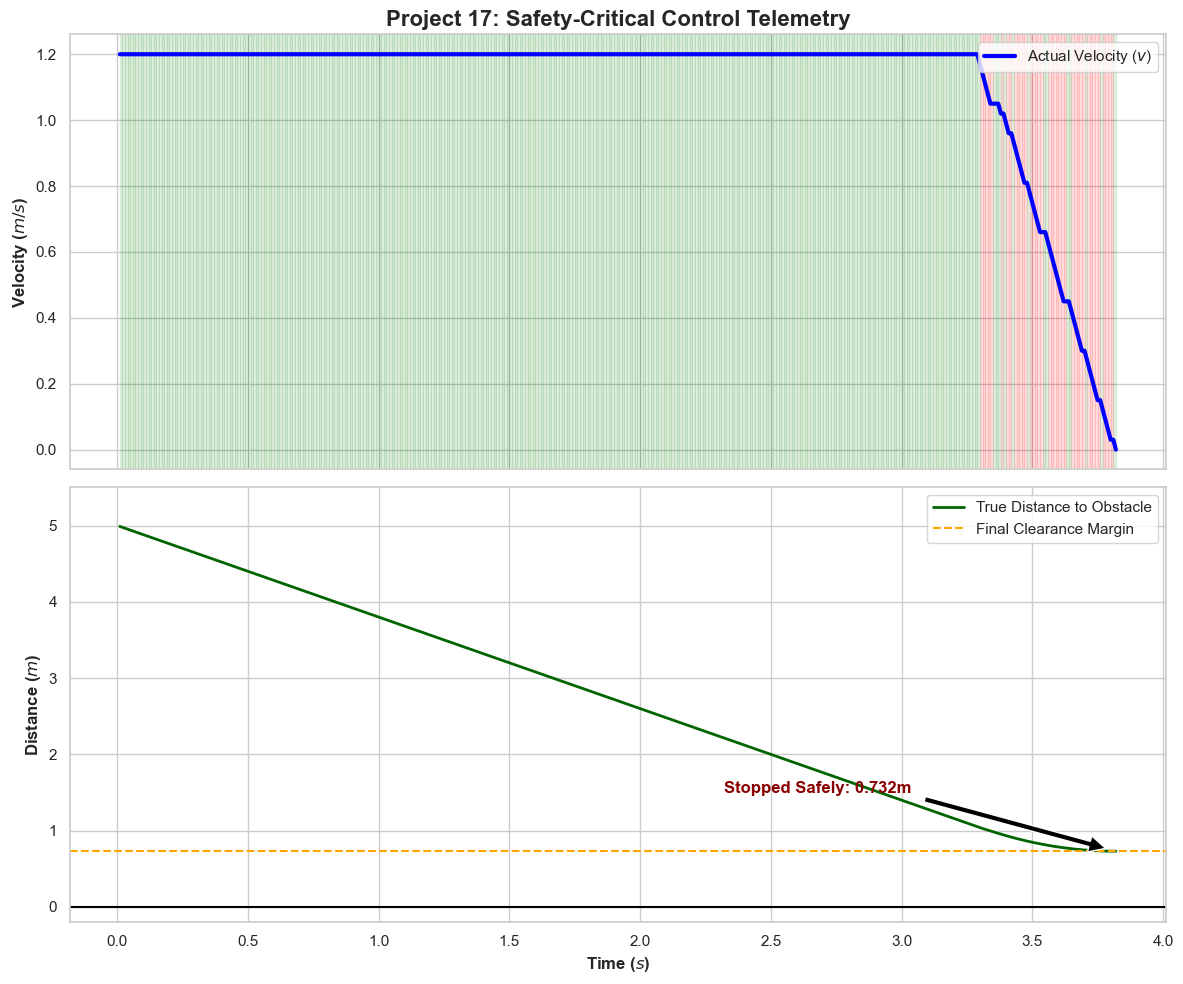

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional theme
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- PLOT 1: VELOCITY & STATES ---
ax1.plot(df_final['Time'], df_final['Velocity'], color='blue', linewidth=3, label='Actual Velocity ($v$)')
ax1.set_ylabel('Velocity ($m/s$)', fontsize=12, fontweight='bold')
ax1.set_title('Project 17: Safety-Critical Control Telemetry', fontsize=16, fontweight='bold')

# Fill background based on State
for i in range(len(df_final)-1):
    color = 'green' if df_final.iloc[i]['State'] == 'CRUISING' else 'red'
    ax1.axvspan(df_final.iloc[i]['Time'], df_final.iloc[i+1]['Time'], color=color, alpha=0.1)

ax1.legend(loc='upper right')

# --- PLOT 2: DISTANCE & THRESHOLD ---
ax2.plot(df_final['Time'], df_final['Distance'], color='darkgreen', linewidth=2, label='True Distance to Obstacle')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5) # The Wall
ax2.axhline(y=0.732, color='orange', linestyle='--', label='Final Clearance Margin')

# Annotate the Stop Point
stop_time = df_final['Time'].iloc[-1]
ax2.annotate(f'Stopped Safely: {0.732:.3f}m', 
             xy=(stop_time, 0.732), xytext=(stop_time-1.5, 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', color='darkred')

ax2.set_ylabel('Distance ($m$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time ($s$)', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.2, 5.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()